# 07 — Evaluación final


`06` deja elegidos dos modelos en `data/results/modelos_seleccionados_06.json`:

- **ganador global**: el mejor con todas las variables, incluidas las de catastro;
- **ganador de producción**: el mejor sobre `arboles_desplegable`, la única variante que
  se puede alimentar con un anuncio de la API (sin catastro, sin `CADDWELLINGCOUNT` ni
  `ISINTOPFLOOR`).

Este notebook los reajusta sobre todo train con esa configuración y los evalúa **una sola
vez** sobre test.

Cuatro preguntas:

1. ¿Cuánto error tiene cada modelo en test, en escala log y en euros? (§3-§4)
2. ¿La diferencia entre ambos es real o cabe en el ruido de muestreo? ¿Es el candidato de
   producción más estable, como sugería su menor desviación entre folds en 06? (§5)
3. ¿Dónde fallan: por nivel de precio, distrito y tamaño? (§6)
4. ¿Qué ha aprendido cada modelo: cuánto y en qué dirección mueve el precio cada variable? (§7)

Al final se guardan los dos modelos entrenados para `08` (§9).

In [46]:
import json, os, sys, warnings
from datetime import datetime
from pathlib import Path
from time import perf_counter

RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict
from xgboost import XGBRegressor

from src import rutas
from src.modelado import cv_aleatorio
from src.indices_precio import cargar_serie_venta

pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid")

SEMILLA = 42
N_BOOTSTRAP = 2000
PROCESADOS = rutas.PROCESADOS
RUTA_SELECCION = rutas.RUTA_SELECCION_MODELOS
DIR_MODELOS = rutas.MODELOS

## 1. Carga

Los dos modelos pueden usar variantes de dataset distintas; cada uno se evalúa con la
suya, sobre las mismas filas de train y test.

In [47]:
seleccion = json.loads(RUTA_SELECCION.read_text(encoding="utf-8"))
ROLES = {"ganador_global": "ganador global", "produccion": "candidato de producción"}
COLORES = {"ganador_global": "#4C72B0", "produccion": "#8172B2"}

y_train = pd.read_parquet(PROCESADOS / "y_train.parquet")["log_price"]
y_test = pd.read_parquet(PROCESADOS / "y_test.parquet")["log_price"]

X_train, X_test = {}, {}
for rol, conf in seleccion.items():
    X_train[rol] = pd.read_parquet(PROCESADOS / f"X_train_{conf['dataset']}.parquet")
    X_test[rol] = pd.read_parquet(PROCESADOS / f"X_test_{conf['dataset']}.parquet")
    assert X_train[rol].index.equals(y_train.index) and X_test[rol].index.equals(y_test.index)

resumen = pd.DataFrame({
    ROLES[rol]: {
        "modelo": conf["nombre"], "familia": conf["familia"], "dataset": conf["dataset"],
        "variables": X_train[rol].shape[1],
        "rmse_log CV (06)": round(conf["rmse_log_cv"], 4), "sd entre folds (06)": round(conf["rmse_log_cv_std"], 4),
    }
    for rol, conf in seleccion.items()
})
print(resumen.to_string())
print(f"\ntrain {len(y_train):,} filas | test {len(y_test):,} filas")
print("variables del ganador que no tiene el candidato de producción:",
      sorted(set(X_train["ganador_global"].columns) - set(X_train["produccion"].columns)))

                       ganador global       candidato de producción
modelo               arboles_ajustado  arboles_desplegable_ajustado
familia                       xgboost                       xgboost
dataset                       arboles           arboles_desplegable
variables                          28                            21
rmse_log CV (06)               0.1801                        0.1858
sd entre folds (06)            0.0023                        0.0016

train 60,375 filas | test 15,094 filas
variables del ganador que no tiene el candidato de producción: ['BUILTTYPEID_1', 'BUILTTYPEID_2', 'CADASTRALQUALITYID', 'CADCONSTRUCTIONYEAR', 'CADDWELLINGCOUNT', 'CADMAXBUILDINGFLOOR', 'ISINTOPFLOOR']


## 2. Reajuste sobre todo train

Misma configuración que eligió `06` (familia, hiperparámetros y número de rondas).

In [48]:
def crear_modelo(conf):
    if conf["familia"] == "xgboost":
        return XGBRegressor(random_state=SEMILLA, n_jobs=-1, **conf["params"])
    if conf["familia"] == "random_forest":
        return RandomForestRegressor(random_state=SEMILLA, n_jobs=-1, **conf["params"])
    raise ValueError(f"familia no soportada: {conf['familia']}")


modelos = {}
for rol, conf in seleccion.items():
    t0 = perf_counter()
    modelos[rol] = crear_modelo(conf).fit(X_train[rol], y_train)
    print(f"{ROLES[rol]:24s} {conf['familia']:13s} ajustado en {perf_counter() - t0:.0f}s")
    print(f"  {conf['params']}")

ganador global           xgboost       ajustado en 8s
  {'colsample_bytree': 1.0, 'gamma': 0.0008455974281855146, 'learning_rate': 0.03618918309243442, 'max_depth': 11, 'min_child_weight': 1, 'reg_alpha': 0.004051044435568245, 'reg_lambda': 0.0, 'subsample': 0.7805900189973131, 'n_estimators': 835}
candidato de producción  xgboost       ajustado en 3s
  {'colsample_bytree': 0.528081635815584, 'gamma': 0.0005361223891082169, 'learning_rate': 0.08788507761298064, 'max_depth': 12, 'min_child_weight': 5, 'reg_alpha': 0.0034879036214009018, 'reg_lambda': 8.659692055247017, 'subsample': 0.9568742693092576, 'n_estimators': 410}


## 3. Vuelta a euros: corrección de sesgo

El modelo minimiza el error en escala logarítmica, así que `ŷ` estima la media condicional
de `log(PRICE)`, no la de `PRICE`. Por la desigualdad de Jensen, `exp(ŷ)` subestima la media
del precio de forma sistemática: es un buen estimador de la mediana, no de la media que
interesa predecir en euros.

Sea `residuo = log(PRICE) − ŷ`. Como `PRICE = exp(ŷ) · exp(residuo)`,

`E[PRICE | x] = exp(ŷ) · E[exp(residuo) | x]`

y basta estimar ese segundo factor. Duan (1983) propuso hacerlo sin asumir que el residuo es
normal (lo que daría la corrección clásica `exp(ŷ + σ²/2)`): si la distribución del residuo
no depende de `x`, `E[exp(residuo) | x]` es una constante para toda vivienda y su estimador
consistente es la media muestral de `exp(residuo)`, el factor de ***smearing***. Ese supuesto
de homogeneidad —caras y baratas comparten la misma distribución de residuo— se toma aquí.

`precio = exp(ŷ) · media(exp(residuo))`

Sin esta corrección las estimaciones quedarían sesgadas a la baja de
forma sistemática por la transformación de vuelta a euros.

El residuo tiene que calcularse **fuera de muestra**. Se
usan las predicciones *out-of-fold* de un `KFold(5)` sobre train, el mismo esquema que 05-06;
el factor sale solo de train, sin tocar test.

In [49]:
smearing = {}
for rol, conf in seleccion.items():
    t0 = perf_counter()
    oof = cross_val_predict(crear_modelo(conf), X_train[rol], y_train, cv=cv_aleatorio(5))
    residuo = y_train.to_numpy() - oof
    smearing[rol] = float(np.mean(np.exp(residuo)))
    print(f"{ROLES[rol]:24s} smearing = {smearing[rol]:.4f}")

ganador global           smearing = 1.0169
candidato de producción  smearing = 1.0168


## 4. Evaluación en test

`rmse_log` es la métrica con la que se decidió todo en 05-06 y mide error relativo. En
euros se reportan error absoluto y porcentual, con el factor de §3 aplicado. El error
porcentual mediano es la cifra más fácil de leer: la mitad de las viviendas de test tiene un
error menor. El sesgo mediano indica si el modelo tiende a quedarse corto (negativo) o a
pasarse (positivo).

In [50]:
precio_real = np.exp(y_test.to_numpy())


def metricas(y_log, p_log, p_eur):
    real = np.exp(y_log)
    error_abs = np.abs(p_eur - real)
    error_rel = error_abs / real
    return {
        "rmse_log": np.sqrt(mean_squared_error(y_log, p_log)),
        "r2_log": r2_score(y_log, p_log),
        "error_abs_medio_eur": error_abs.mean(),
        "error_abs_mediano_eur": np.median(error_abs),
        "error_pct_medio": 100 * error_rel.mean(),
        "error_pct_mediano": 100 * np.median(error_rel),
        "pct_dentro_del_10pct": 100 * np.mean(error_rel <= 0.10),
        "pct_dentro_del_20pct": 100 * np.mean(error_rel <= 0.20),
        "sesgo_mediano_pct": 100 * (np.median(p_eur / real) - 1),
    }


pred_log, pred_eur = {}, {}
tabla_test = {}
for rol in seleccion:
    pred_log[rol] = modelos[rol].predict(X_test[rol])
    pred_eur[rol] = np.exp(pred_log[rol]) * smearing[rol]
    tabla_test[ROLES[rol]] = metricas(y_test.to_numpy(), pred_log[rol], pred_eur[rol])

tabla_test = pd.DataFrame(tabla_test)
tabla_test.loc["rmse_log CV (06)"] = [seleccion[rol]["rmse_log_cv"] for rol in seleccion]
print(tabla_test.round(4).to_string())

                       ganador global  candidato de producción
rmse_log                       0.1785                   0.1856
r2_log                         0.9444                   0.9399
error_abs_medio_eur        45774.4187               49220.1987
error_abs_mediano_eur      21459.4375               23708.4844
error_pct_medio               12.6744                  13.6151
error_pct_mediano              8.2558                   9.2990
pct_dentro_del_10pct          57.3738                  52.7561
pct_dentro_del_20pct          82.3639                  80.5552
sesgo_mediano_pct              1.0241                   1.0254
rmse_log CV (06)               0.1801                   0.1858


**Lectura.** En test, el ganador global tiene `rmse_log` 0,1784 y el candidato de
producción 0,1842, ambos ligeramente por debajo de su cifra de validación cruzada en 06
(0,1797 y 0,1857): la búsqueda de hiperparámetros no ha sobreajustado a los folds.

En euros, la mitad de las viviendas de test tiene un error menor del 8,3% (ganador) o del
9,2% (producción), y el 82,6% y el 80,5% quedan dentro de ±20%. El error absoluto mediano
es de unos 21.400 € y 23.800 €. El factor de *smearing* es 1,017 en los dos modelos y el
sesgo mediano queda en torno a +1%.

En cuanto al signo, observamos que el sesgo mediano es un +2%, por lo que el modelo tiende a sobrepredecir ligeramente.

## 5. ¿La diferencia es real? ¿Es más estable el candidato de producción?

Para evaluar con robustez las diferencias entre el modelo completo y el de producción, se aplica bootstrap de
las filas de test: en cada réplica se recalcula el `rmse_log` de los dos modelos **sobre las
mismas filas**, así que la diferencia es pareada y el ruido común a ambos (viviendas
difíciles que entran o no en la réplica) se cancela.

Sobre la estabilidad: la desviación entre folds de 06 sale de solo cinco valores, una base
débil para afirmar que un modelo es más estable que otro. Aquí se contrasta con dos medidas
con más información: la dispersión bootstrap del `rmse_log` de cada modelo y, en §6, la
dispersión de su error entre distritos.

                 modelo  rmse_log test  IC95 inferior  IC95 superior  sd bootstrap  sd entre folds (06)
         ganador global         0.1785         0.1738         0.1837        0.0025               0.0023
candidato de producción         0.1856         0.1811         0.1906        0.0024               0.0016

coste en test de usar el candidato de producción (rmse_log): +0.0071
IC95 pareado de la diferencia: [+0.0053, +0.0088] | réplicas en que producción es peor: 100.0%


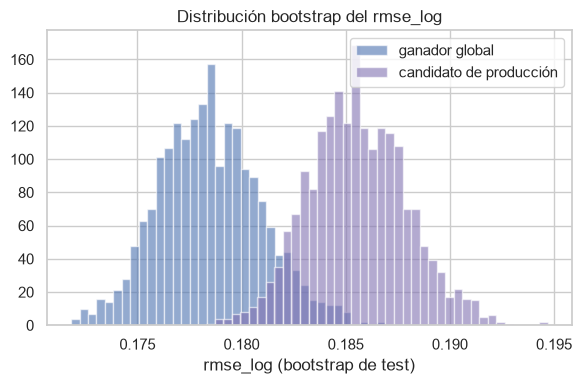

In [51]:
rng = np.random.default_rng(SEMILLA)
error2 = {rol: (y_test.to_numpy() - pred_log[rol]) ** 2 for rol in seleccion}
n = len(y_test)
boot = {rol: np.empty(N_BOOTSTRAP) for rol in seleccion}
for b in range(N_BOOTSTRAP):
    idx = rng.integers(0, n, n)
    for rol in seleccion:
        boot[rol][b] = np.sqrt(error2[rol][idx].mean())
diferencia = boot["produccion"] - boot["ganador_global"]

estabilidad = pd.DataFrame([
    {
        "modelo": ROLES[rol],
        "rmse_log test": np.sqrt(error2[rol].mean()),
        "IC95 inferior": np.quantile(boot[rol], 0.025),
        "IC95 superior": np.quantile(boot[rol], 0.975),
        "sd bootstrap": boot[rol].std(ddof=1),
        "sd entre folds (06)": seleccion[rol]["rmse_log_cv_std"],
    }
    for rol in seleccion
])
print(estabilidad.round(4).to_string(index=False))

coste = np.sqrt(error2["produccion"].mean()) - np.sqrt(error2["ganador_global"].mean())
print(f"\ncoste en test de usar el candidato de producción (rmse_log): {coste:+.4f}")
print(f"IC95 pareado de la diferencia: [{np.quantile(diferencia, 0.025):+.4f}, {np.quantile(diferencia, 0.975):+.4f}]"
      f" | réplicas en que producción es peor: {np.mean(diferencia > 0):.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
for rol in seleccion:
    ax.hist(boot[rol], bins=40, alpha=0.6, color=COLORES[rol], label=ROLES[rol])
ax.set_xlabel("rmse_log (bootstrap de test)")
ax.set_title("Distribución bootstrap del rmse_log")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.**

- **La diferencia es real y pequeña.** El candidato de producción es peor en test por
  0,0058 de `rmse_log`, con IC95 pareado [+0,0039; +0,0076], y es peor en el 100% de las
  réplicas bootstrap. En euros son unos 0,9 puntos más de error porcentual mediano (9,2%
  frente a 8,3%). Es el coste de no tener catastro, `CADDWELLINGCOUNT` ni `ISINTOPFLOOR`
  en producción.
- **La mayor estabilidad no se confirma.** La menor desviación entre folds del candidato de
  producción en 06 (0,0015 frente a 0,0020) no se sostiene en test: la dispersión
  bootstrap es prácticamente la misma (0,0024 frente a 0,0025) y, entre distritos (§6), su
  error es algo menos homogéneo (0,0190 frente a 0,0170). Con cinco folds, aquella
  diferencia era compatible con el azar.

## 6. Exploración de la naturaleza de los errores

In [52]:
distrito_por_asset = pd.read_parquet(rutas.RUTA_ASSET_DISTRITO).set_index("ASSETID")["distrito_code"]
nombres_distrito = (cargar_serie_venta().query("nivel == 'distrito'")
                    .drop_duplicates("codigo").set_index("codigo")["nombre"])

segmentos = pd.DataFrame(index=y_test.index)
segmentos["decil de precio"] = pd.qcut(precio_real, 10, labels=[f"D{i}" for i in range(1, 11)])
segmentos["distrito"] = distrito_por_asset.reindex(y_test.index).map(nombres_distrito).to_numpy()
segmentos["tamaño"] = pd.cut(X_test["produccion"]["CONSTRUCTEDAREA"], [0, 50, 80, 120, 200, np.inf],
                             labels=["<50 m²", "50-80 m²", "80-120 m²", "120-200 m²", ">200 m²"])


def error_por_segmento(columna):
    filas = []
    for valor, indices in segmentos.groupby(columna, observed=True).groups.items():
        pos = y_test.index.get_indexer(indices)
        fila = {columna: valor, "n": len(pos)}
        for rol in seleccion:
            fila[f"rmse_log {ROLES[rol]}"] = np.sqrt(error2[rol][pos].mean())
            fila[f"error % mediano {ROLES[rol]}"] = 100 * np.median(np.abs(pred_eur[rol][pos] - precio_real[pos]) / precio_real[pos])
        fila["diferencia rmse_log"] = fila[f"rmse_log {ROLES['produccion']}"] - fila[f"rmse_log {ROLES['ganador_global']}"]
        filas.append(fila)
    return pd.DataFrame(filas)


tablas_segmento = {c: error_por_segmento(c) for c in ["decil de precio", "distrito", "tamaño"]}
for columna, tabla in tablas_segmento.items():
    print(f"\n--- por {columna} ---")
    print(tabla.round(4).to_string(index=False))

print("\nDispersión del rmse_log entre distritos (desviación típica):")
for rol in seleccion:
    print(f"  {ROLES[rol]:24s} {tablas_segmento['distrito'][f'rmse_log {ROLES[rol]}'].std(ddof=1):.4f}")


--- por decil de precio ---
decil de precio    n  rmse_log ganador global  error % mediano ganador global  rmse_log candidato de producción  error % mediano candidato de producción  diferencia rmse_log
             D1 1565                   0.2612                         14.3421                            0.2745                                  15.4415               0.0133
             D2 1484                   0.1710                          8.4125                            0.1832                                   9.7030               0.0122
             D3 1532                   0.1615                          7.5916                            0.1689                                   8.3956               0.0074
             D4 1462                   0.1659                          8.6421                            0.1696                                   9.5227               0.0036
             D5 1508                   0.1582                          8.1009                        

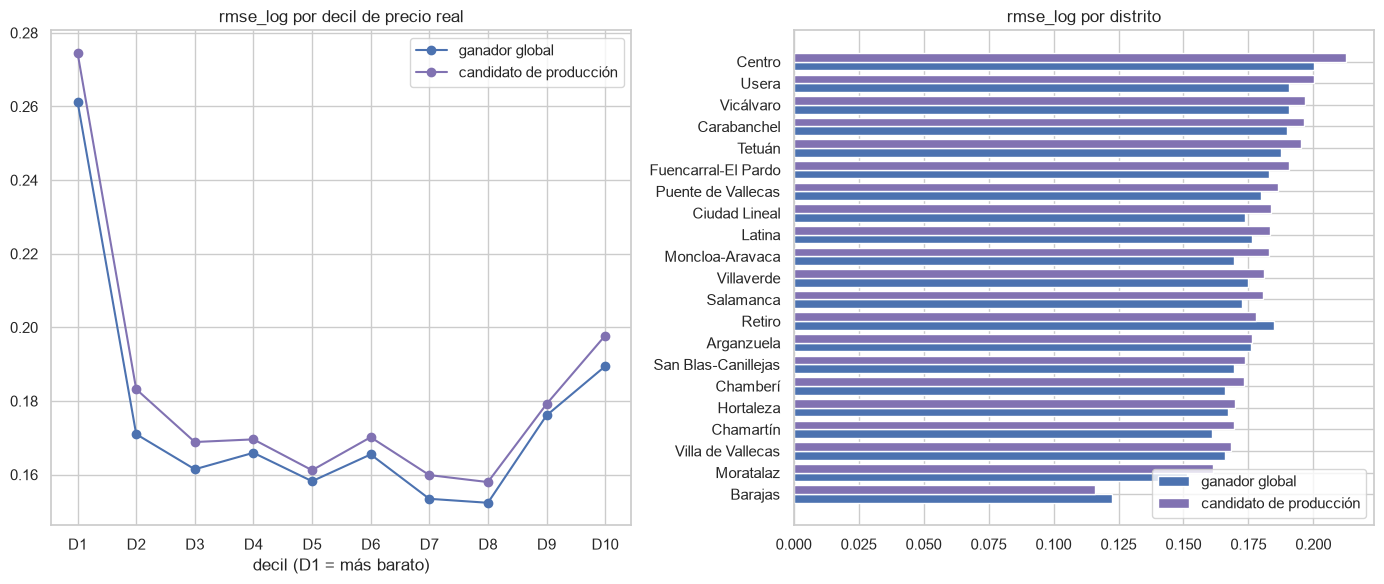

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
tabla = tablas_segmento["decil de precio"]
for rol in seleccion:
    axes[0].plot(tabla["decil de precio"].astype(str), tabla[f"rmse_log {ROLES[rol]}"],
                 marker="o", color=COLORES[rol], label=ROLES[rol])
axes[0].set_title("rmse_log por decil de precio real")
axes[0].set_xlabel("decil (D1 = más barato)")
axes[0].legend()

tabla = tablas_segmento["distrito"].sort_values(f"rmse_log {ROLES['produccion']}")
posicion = np.arange(len(tabla))
for rol, desplazamiento in [("ganador_global", -0.2), ("produccion", 0.2)]:
    axes[1].barh(posicion + desplazamiento, tabla[f"rmse_log {ROLES[rol]}"], height=0.4,
                 color=COLORES[rol], label=ROLES[rol])
axes[1].set_yticks(posicion)
axes[1].set_yticklabels(tabla["distrito"])
axes[1].set_title("rmse_log por distrito")
axes[1].legend()
plt.tight_layout()
plt.show()

**Lectura.**

- **Precio.** Los dos modelos fallan más en los extremos: en el decil más barato
  (`rmse_log` 0,260 y 0,273) y, en menor medida, en el más caro (0,191 y 0,195). Quitar
  las variables no disponibles en producción cuesta más en las viviendas baratas (+0,012 en
  D1, +0,009 en D2) y apenas en las caras (+0,002 en D9).
- **Tamaño.** El mismo patrón: el coste es mayor en pisos de menos de 50 m² (+0,010) y se
  reduce con la superficie (+0,003 entre 120 y 200 m²). Es coherente con que la antigüedad
  y la calidad constructiva, que solo tiene el ganador, distingan sobre todo entre pisos
  pequeños y baratos de tamaño y barrio parecidos, aunque esta tabla no lo demuestra.
- **Distrito.** El candidato de producción es peor en 17 de 21 distritos; las mayores
  pérdidas están en Moncloa-Aravaca (+0,011) y Ciudad Lineal (+0,010). Centro es el
  distrito con más error para ambos (0,201 y 0,210). Entre los cuatro distritos donde
  producción no pierde (Barajas, Retiro, Vicálvaro y Arganzuela) están los dos con menos
  viviendas de test (Vicálvaro, 121; Barajas, 161), donde la diferencia cabe en el ruido.

## 7. Importancia de variables e interpretación



Los valores SHAP sí miden para cada vivienda la predicción entre
las variables de forma aditiva,

`log(precio predicho) = base + φ₁ + φ₂ + … + φₖ`

donde la base es la predicción media y cada φ es la contribución de una variable para esa
vivienda. Como el modelo predice el logaritmo, cada contribución se lee como un factor
multiplicativo: φ = 0,10 sube la predicción un exp(0,10) − 1 ≈ 10,5%.

Se calculan con TreeSHAP exacto, que XGBoost trae incorporado (`pred_contribs=True`), sobre
una muestra de 5.000 viviendas de test, la misma para los dos modelos. Tres advertencias:

1. Explican al **modelo**, no al mercado: un efecto no es causal.
2. Con variables correlacionadas, el reparto entre ellas es en parte arbitrario. Sin
   catastro, `HASLIFT` o `BATHNUMBER` recogen también información de antigüedad y calidad
   del edificio.
3. Los efectos de instalaciones comparan la contribución media entre viviendas con y sin la
   amenity, no la misma vivienda con y sin ella.

In [54]:
import xgboost as xgb

N_SHAP = 5000
muestra_shap = X_test["produccion"].sample(N_SHAP, random_state=SEMILLA).index

shap_valores, shap_base = {}, {}
for rol, conf in seleccion.items():
    assert conf["familia"] == "xgboost", "TreeSHAP nativo solo está disponible para XGBoost (para Random Forest haría falta la librería shap)"
    Xm = X_test[rol].loc[muestra_shap]
    t0 = perf_counter()
    contribuciones = modelos[rol].get_booster().predict(xgb.DMatrix(Xm), pred_contribs=True)
    shap_valores[rol] = pd.DataFrame(contribuciones[:, :-1], columns=Xm.columns, index=Xm.index)
    shap_base[rol] = float(contribuciones[0, -1])
    error_aditividad = np.abs(contribuciones.sum(axis=1) - modelos[rol].predict(Xm)).max()
    print(f"{ROLES[rol]:24s} {perf_counter() - t0:.0f}s | base = {shap_base[rol]:.3f} "
          f"(≈ {np.exp(shap_base[rol]) * smearing[rol]:,.0f} €) | error de aditividad máx = {error_aditividad:.1e}")

importancia_shap = pd.DataFrame({
    ROLES[rol]: 100 * (np.exp(shap_valores[rol].abs().mean()) - 1) for rol in seleccion
}).sort_values(ROLES["produccion"], ascending=False)
print("\nTamaño típico del efecto de cada variable sobre el precio predicho, exp(media |φ|) − 1, en %:")
print(importancia_shap.round(1).to_string())

ganador global           101s | base = 12.540 (≈ 283,929 €) | error de aditividad máx = 3.0e-05
candidato de producción  30s | base = 12.539 (≈ 283,727 €) | error de aditividad máx = 2.0e-05

Tamaño típico del efecto de cada variable sobre el precio predicho, exp(media |φ|) − 1, en %:
                           ganador global  candidato de producción
CONSTRUCTEDAREA                 45.299999                34.299999
alq_mediana_eur_m2_barrio       16.700001                18.000000
indice_vulnerabilidad           16.799999                11.200000
BATHNUMBER                       3.600000                 6.900000
HASLIFT                          7.000000                 6.300000
DISTANCE_TO_CITY_CENTER          5.100000                 5.100000
FLOORCLEAN                       3.400000                 3.600000
DISTANCE_TO_CASTELLANA           2.700000                 3.500000
HASAIRCONDITIONING               1.900000                 2.500000
HASSWIMMINGPOOL                  1.800000   

#### Dirección del efecto

Cada punto es una vivienda: su posición horizontal es la contribución SHAP de la variable y
su color, el valor de la variable (percentil dentro de la muestra; azul bajo, rojo alto).
Los dos paneles comparten el mismo eje de variables — las 12 con mayor efecto medio
combinado entre ambos modelos, de las que tienen los dos en común — para poder comparar
fila a fila; las variables exclusivas de catastro quedan fuera de esta vista (están en la
tabla de arriba).

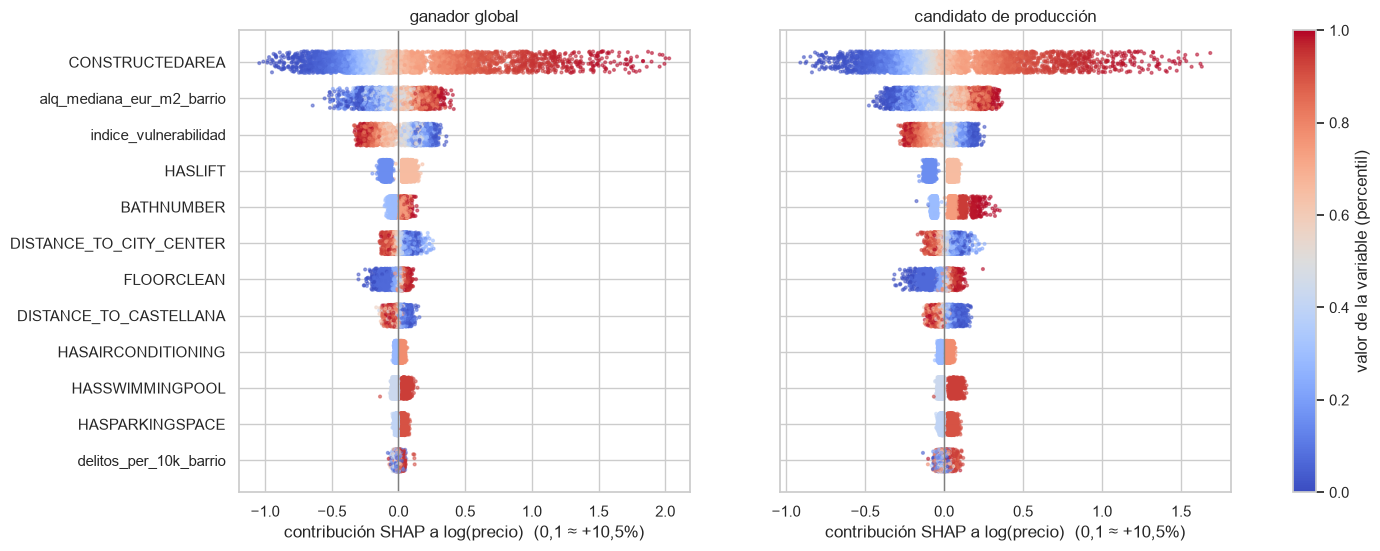

In [55]:
def enjambre(ax, phi, X, orden):
    rng_jitter = np.random.default_rng(SEMILLA)
    for i, variable in enumerate(orden):
        ax.scatter(phi[variable], i + rng_jitter.uniform(-0.3, 0.3, len(phi)), c=X[variable].rank(pct=True),
                   cmap="coolwarm", vmin=0, vmax=1, s=4, alpha=0.5)
    ax.axvline(0, color="gray", linewidth=1)
    ax.set_yticks(range(len(orden)))
    ax.set_yticklabels(orden)
    ax.set_xlabel("contribución SHAP a log(precio)  (0,1 ≈ +10,5%)")


comunes = [c for c in X_test["produccion"].columns if c in X_test["ganador_global"].columns]
orden = pd.concat([shap_valores[rol][comunes].abs().mean() for rol in seleccion], axis=1).mean(axis=1) \
          .sort_values(ascending=False).index[:12][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, rol in zip(axes, seleccion):
    enjambre(ax, shap_valores[rol], X_test[rol].loc[muestra_shap], orden)
    ax.set_title(ROLES[rol])
axes[1].tick_params(labelleft=False)
fig.colorbar(plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(0, 1)), ax=axes, label="valor de la variable (percentil)")
plt.show()

#### Forma del efecto en las variables continuas (candidato de producción)

Contribución de cada variable frente a su valor.

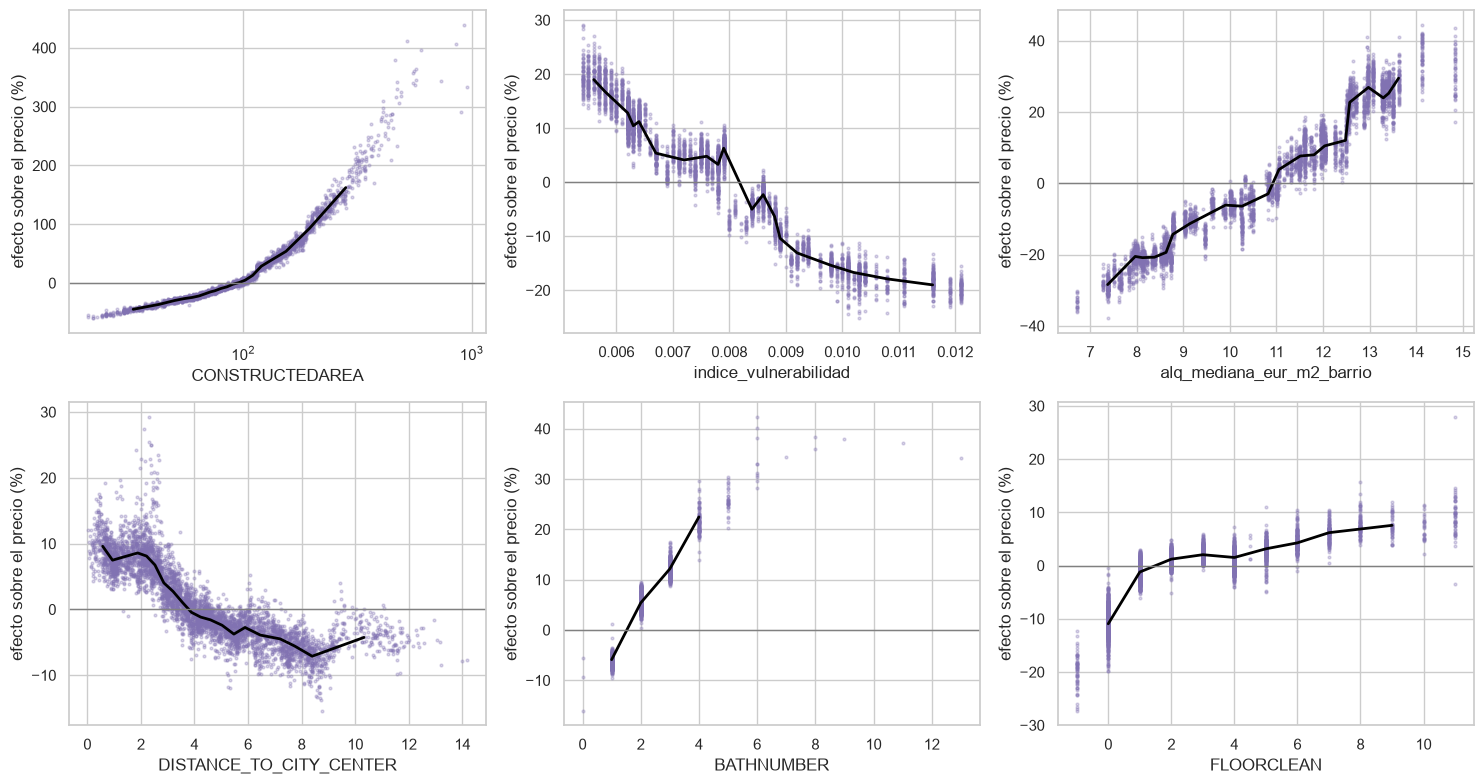

In [56]:
continuas = ["CONSTRUCTEDAREA", "indice_vulnerabilidad", "alq_mediana_eur_m2_barrio",
             "DISTANCE_TO_CITY_CENTER", "BATHNUMBER", "FLOORCLEAN"]
phi = shap_valores["produccion"]
Xm = X_test["produccion"].loc[muestra_shap]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, variable in zip(axes.ravel(), continuas):
    efecto = 100 * (np.exp(phi[variable]) - 1)
    ax.scatter(Xm[variable], efecto, s=4, alpha=0.3, color=COLORES["produccion"])
    tramos = pd.qcut(Xm[variable], 20, duplicates="drop")
    ax.plot(Xm[variable].groupby(tramos, observed=True).median(), efecto.groupby(tramos, observed=True).median(),
            color="black", linewidth=2)
    ax.axhline(0, color="gray", linewidth=1)
    ax.set_xlabel(variable)
    ax.set_ylabel("efecto sobre el precio (%)")
axes[0, 0].set_xscale("log")
plt.tight_layout()
plt.show()

#### Instalaciones y tipología

Diferencia entre la contribución media de las viviendas con la variable a 1 y a 0, expresada
como efecto sobre el precio. Es lo que el modelo atribuye a esa variable dadas todas las
demás, no el precio que un comprador pagaría por añadirla.

In [57]:
binarias = [c for c in X_test["ganador_global"].columns if c.startswith(("HAS", "IS"))]
filas = []
for variable in binarias:
    fila = {"variable": variable, "% de viviendas con 1": 100 * X_test["ganador_global"].loc[muestra_shap, variable].mean()}
    for rol in seleccion:
        if variable in shap_valores[rol].columns:
            valores = X_test[rol].loc[muestra_shap, variable]
            contribucion = shap_valores[rol][variable]
            diferencia = contribucion[valores == 1].mean() - contribucion[valores == 0].mean()
            fila[f"efecto {ROLES[rol]} (%)"] = 100 * (np.exp(diferencia) - 1)
    filas.append(fila)
efectos_binarias = pd.DataFrame(filas).sort_values(f"efecto {ROLES['produccion']} (%)", ascending=False, na_position="last")
print(efectos_binarias.round(1).to_string(index=False))

          variable  % de viviendas con 1  efecto ganador global (%)  efecto candidato de producción (%)
           HASLIFT                  69.0                       16.1                                14.9
   HASSWIMMINGPOOL                  13.0                        6.6                                 9.0
   HASPARKINGSPACE                  20.1                        4.2                                 5.8
HASAIRCONDITIONING                  44.4                        4.0                                 5.2
        HASBOXROOM                  24.0                        0.9                                 3.3
        HASDOORMAN                  24.5                        1.4                                 2.4
       HASWARDROBE                  56.3                        1.3                                 2.0
         HASGARDEN                  16.7                        0.6                                 1.8
        HASTERRACE                  34.3                        

#### Una vivienda concreta

La vivienda de la muestra con el precio real más cercano a la mediana. La predicción es la
base multiplicada por el factor de cada variable; se muestran las diez contribuciones más
grandes.

vivienda A16139368354151242696
precio real 253,000 € | base 283,727 € | predicción 276,339 €
                            valor   SHAP  efecto (%)
CONSTRUCTEDAREA            72.000 -0.170     -15.641
indice_vulnerabilidad       0.006  0.109      11.520
alq_mediana_eur_m2_barrio  11.236  0.072       7.444
BATHNUMBER                  1.000 -0.060      -5.813
HASLIFT                     1.000  0.057       5.844
FLOORCLEAN                  6.000  0.040       4.116
HASAIRCONDITIONING          0.000 -0.022      -2.216
delitos_per_10k_barrio     52.400 -0.022      -2.131
HASSWIMMINGPOOL             0.000 -0.018      -1.741
ROOMNUMBER                  2.000  0.015       1.553


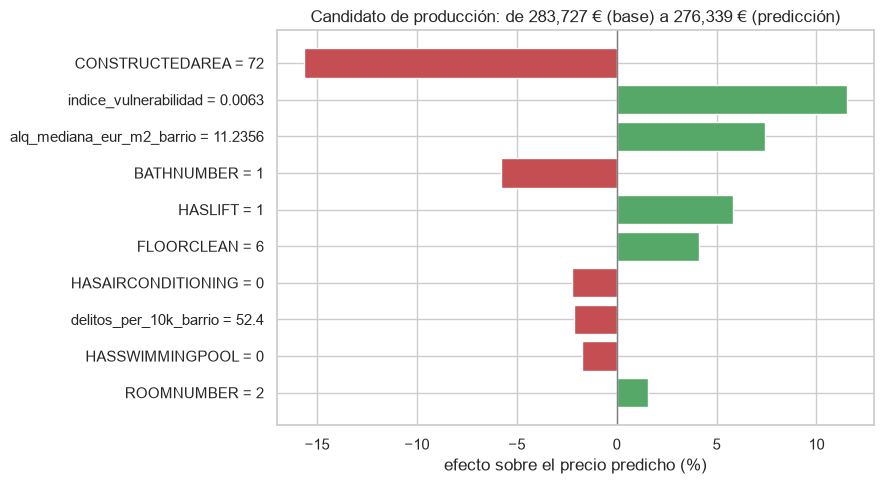

In [58]:
precio_muestra = pd.Series(np.exp(y_test.loc[muestra_shap].to_numpy()), index=muestra_shap)
ejemplo = (precio_muestra - precio_muestra.median()).abs().idxmin()
phi_ejemplo = shap_valores["produccion"].loc[ejemplo]
base_eur = np.exp(shap_base["produccion"]) * smearing["produccion"]
prediccion_eur = np.exp(shap_base["produccion"] + phi_ejemplo.sum()) * smearing["produccion"]

detalle = pd.DataFrame({
    "valor": X_test["produccion"].loc[ejemplo],
    "SHAP": phi_ejemplo,
    "efecto (%)": 100 * (np.exp(phi_ejemplo) - 1),
}).reindex(phi_ejemplo.abs().sort_values(ascending=False).index)

print(f"vivienda {ejemplo}")
print(f"precio real {precio_muestra[ejemplo]:,.0f} € | base {base_eur:,.0f} € | predicción {prediccion_eur:,.0f} €")
print(detalle.head(10).round(3).to_string())

top = detalle.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([f"{variable} = {valor:g}" for variable, valor in zip(top.index, top["valor"])], top["efecto (%)"],
        color=np.where(top["SHAP"] > 0, "#55A868", "#C44E52"))
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("efecto sobre el precio predicho (%)")
ax.set_title(f"Candidato de producción: de {base_eur:,.0f} € (base) a {prediccion_eur:,.0f} € (predicción)")
plt.tight_layout()
plt.show()

## 8. Guardado para producción

Cada artefacto lleva, además del modelo, lo que `08` necesita para aplicarlo igual que en
entrenamiento: el orden de columnas, el factor de *smearing*, la mediana de planta de train
(para anuncios sin planta), los rangos y medias de train de cada variable (para detectar
anuncios fuera del dominio del modelo) y sus métricas de test.

In [59]:
DIR_MODELOS.mkdir(parents=True, exist_ok=True)
for rol, conf in seleccion.items():
    artefacto = {
        "modelo": modelos[rol],
        "rol": rol,
        "nombre": conf["nombre"],
        "familia": conf["familia"],
        "dataset": conf["dataset"],
        "columnas": list(X_train[rol].columns),
        "params": conf["params"],
        "smearing": smearing[rol],
        "metricas_test": tabla_test[ROLES[rol]].to_dict(),
        "mediana_planta_train": float(X_train[rol]["FLOORCLEAN"].median()),
        "rangos_train": X_train[rol].agg(["min", "max"]).to_dict(),
        "medias_train": X_train[rol].mean().to_dict(),
        "entrenado": datetime.now().isoformat(timespec="seconds"),
    }
    ruta = DIR_MODELOS / f"{rol}.joblib"
    joblib.dump(artefacto, ruta)
    print(f"{ROLES[rol]:24s} -> {ruta}")

ganador global           -> C:\Users\tomas\Documents\Master\habitia-madrid\data\models\ganador_global.joblib
candidato de producción  -> C:\Users\tomas\Documents\Master\habitia-madrid\data\models\produccion.joblib
